In [106]:
## Get needed functions
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from numpy import float32
import torch 
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
import torch.nn as nn
from torch.utils.data import random_split

Load in the previously trained model

In [107]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

## Load previously defined functions
from src.dataset import SingleCellDataset
from torch.utils.data import DataLoader
from src.model import SingleCellModel
from src.evaluate import evaluate

## Load processed data
data = torch.load("../data/processed_data.pt")
X_tensor = data["X"]
y_tensor = data["y"]
class_names = data['class_names']

## Recreate dataset
dataset = SingleCellDataset(X_tensor, y_tensor)

## Load split indexes and recreate data split
split = torch.load("../data/data_split.pt")

train_dataset = Subset(dataset, split["train_idx"])
validate_dataset = Subset(dataset, split["validate_idx"])
test_dataset = Subset(dataset, split["test_idx"])

## Create test dataloader 
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## Load the best parameters and number of classes
info = torch.load("../data/model_info.pt")

best_params = info["best_params"]
num_classes = info["num_classes"]
num_features = info["num_features"]


## Recreate model
final_model = SingleCellModel(
    num_features=num_features,
    num_classes=num_classes,
    hidden_size1=best_params["hidden_size1"],
    hidden_size2=best_params["hidden_size2"],
    dropout_rate=best_params["dropout_rate"],
)

## Load model weights
final_model.load_state_dict(torch.load("../models/final_model.pt"))
final_model.eval()

# Evaluate

test_accuracy, test_loss = evaluate(test_dataloader, final_model)

print(
    f"Test accuracy: {test_accuracy:.4f} | "
    f"Test loss: {test_loss:.4f}")

## Test accuracy: 0.8190 | Test loss: 0.5748

Test accuracy: 0.8190 | Test loss: 0.5959


Although the Accuracy is about the same for the optimized function, the loss is a bit better. to 0.5748 down from Baseline loss of 0.8575. This is a very small dataset, so improvements in accuracy may be a bit difficult. Also the tuning function optimized based on loss and not accuracy. There are 105 cells in the test and validation set. The difference in accuracy corrsponds to 86 vs 87 correct calls respectively. This is not meaningfully different. Let's see where these errors fall using a confusion matrix.

                              precision    recall  f1-score   support

              CD14+ Monocyte      0.789     0.789     0.789        19
                     CD19+ B      1.000     0.929     0.963        14
                       CD34+      1.000     1.000     1.000         2
             CD4+/CD25 T Reg      0.625     1.000     0.769        10
  CD4+/CD45RA+/CD25- Naive T      0.000     0.000     0.000         1
         CD4+/CD45RO+ Memory      0.500     0.333     0.400         3
                    CD56+ NK      1.000     0.800     0.889         5
            CD8+ Cytotoxic T      0.667     0.750     0.706         8
CD8+/CD45RA+ Naive Cytotoxic      1.000     0.429     0.600         7
                   Dendritic      0.865     0.889     0.877        36

                    accuracy                          0.819       105
                   macro avg      0.745     0.692     0.699       105
                weighted avg      0.831     0.819     0.812       105



/Users/shanewarland/miniforge3/envs/singlecell/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shanewarland/miniforge3/envs/singlecell/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shanewarland/miniforge3/envs/singlecell/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

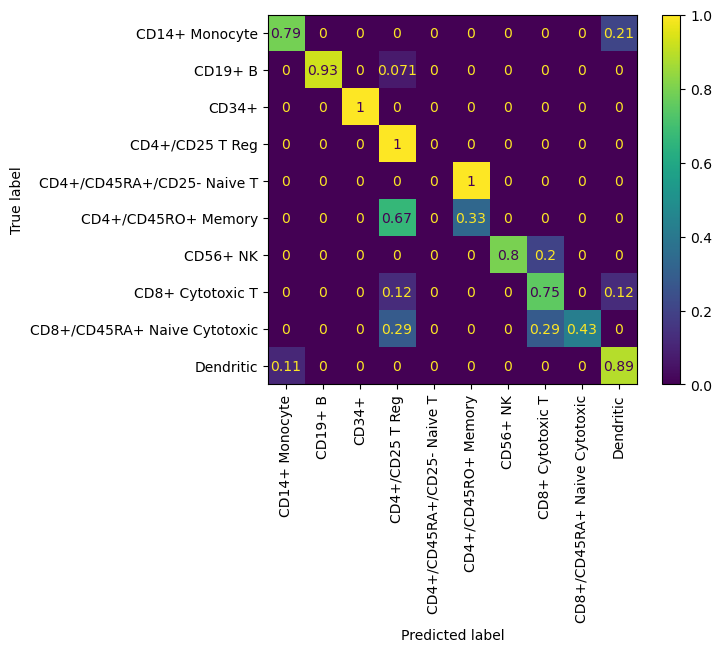

In [108]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch

all_predictions = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        logits = final_model(X_batch)
        predictions = logits.argmax(dim=1)

        all_predictions.extend(predictions.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=3))

ConfusionMatrixDisplay.from_predictions(
    all_labels,
    all_predictions,
    display_labels=class_names,
    xticks_rotation=90,
    normalize='true'
)

plt.show()


Well that explains why model accuracy was struggling to improve. Some of these classes have only a single cell in the test group. The low sample size is making improving accuracy a bit difficult. Lets move on with some final analyses. 

Let's calculate F1 score per class as easier to interpret metric. Barplot will work. 

                              precision    recall  f1-score  support
CD14+ Monocyte                 0.789474  0.789474  0.789474     19.0
CD19+ B                        1.000000  0.928571  0.962963     14.0
CD34+                          1.000000  1.000000  1.000000      2.0
CD4+/CD25 T Reg                0.625000  1.000000  0.769231     10.0
CD4+/CD45RA+/CD25- Naive T     0.000000  0.000000  0.000000      1.0
CD4+/CD45RO+ Memory            0.500000  0.333333  0.400000      3.0
CD56+ NK                       1.000000  0.800000  0.888889      5.0
CD8+ Cytotoxic T               0.666667  0.750000  0.705882      8.0
CD8+/CD45RA+ Naive Cytotoxic   1.000000  0.428571  0.600000      7.0
Dendritic                      0.864865  0.888889  0.876712     36.0
Index(['CD14+ Monocyte', 'CD19+ B', 'CD34+', 'CD4+/CD25 T Reg',
       'CD4+/CD45RA+/CD25- Naive T', 'CD4+/CD45RO+ Memory', 'CD56+ NK',
       'CD8+ Cytotoxic T', 'CD8+/CD45RA+ Naive Cytotoxic', 'Dendritic'],
      dtype='object')


/Users/shanewarland/miniforge3/envs/singlecell/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shanewarland/miniforge3/envs/singlecell/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shanewarland/miniforge3/envs/singlecell/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

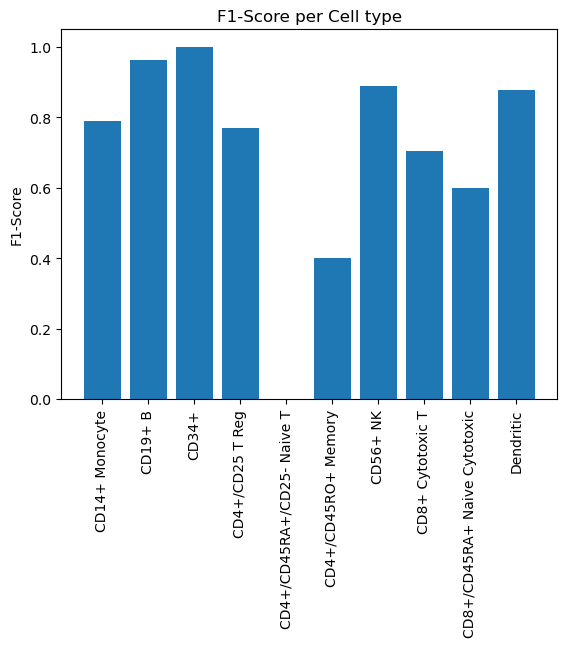

In [109]:
summary_stats = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=3, output_dict=True)
df = pd.DataFrame(summary_stats).transpose()
df_class = df.drop(['accuracy', 'macro avg', 'weighted avg'])
print(df_class)

cell_types = df_class.index
F1_scores = df_class['f1-score']
print(cell_types)

plt.bar(cell_types, F1_scores)
plt.xticks(rotation=90)
plt.ylabel('F1-Score')
plt.title('F1-Score per Cell type')
plt.show()



This is quite telling. So for the Naive T and memory, which has lowest F1-score, they had the lowest sample size, 1, 3 respectively Hard to tune a neural net on such limited data. Below is barplot highlighting this.

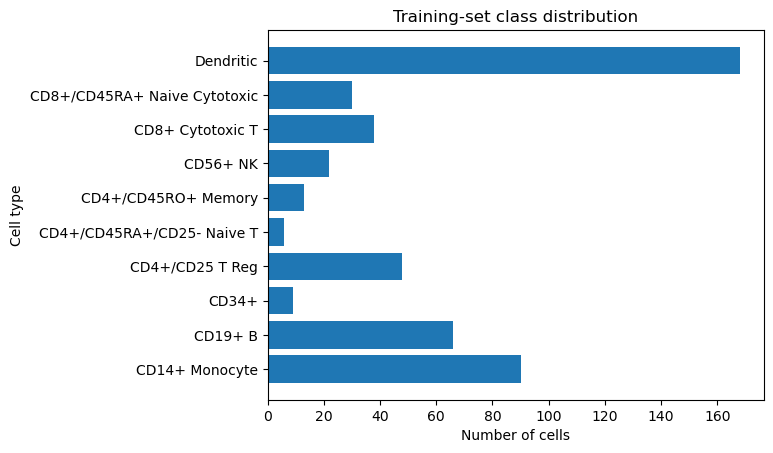

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

train_labels = y_tensor[split['train_idx']].numpy()

class_counts = pd.Series(train_labels).value_counts()

class_distribution = pd.DataFrame({
    "class_name": class_names,
    "count": class_counts.reindex(
        range(len(class_names)),
        fill_value=0,
    ).values,
})

class_distribution

plt.barh(class_distribution["class_name"], class_distribution["count"])
plt.xlabel("Number of cells")
plt.ylabel("Cell type")
plt.title("Training-set class distribution")
plt.show()


Ok the cells with the fewest counts also had the worst F1-scores. Neural nets are data hungry so unsurprising that the ones with barely any occurances were not classified well. Overall accuracy of ~82%. Not bad all things considered since the misclassifications were mostly due to these low sample size classes. 